# Project: The Retinal OCT Project

## Table of Contents

- <a href='#dataset'>1. Data Set Description</a>
- <a href="#wrangling">2. Data Wrangling</a>
    - <a href='#wranglingRetinal'>2.3.  Dataset Of Retinal OCT</a>
- <a href='#info'>4.1. Show Information Of DataSet</a>
- <a href="#eda">3. Exploratory Data Analysis</a>
- <a href='#pre'>4. Preprocessing DataSet</a>
    - <a href='#save'>4.2. Save DataSet After Preprocessing</a>
- <a href='#cnn'>5. CNN Model</a>
    - <a href='#aug'>5.1. Data Augmentation</a>
        - <a href='#apply'>5.1.1. Apply</a>
        - <a href='#demo'>5.1.2. Demo</a>
    - <a href='#build'>5.2. Model Building</a>
        - <a href='#scrath'>5.2.1. Model from Scratch </a>
             - <a href='#scrathf'>5.2.1.1. Model from Simple Scratch</a>
             - <a href='#scratchComplex'>5.2.1.2. Model from Scratch More Complex</a>
     
        - <a href='#MobileNet'>5.2.5. Model MobileNet</a>
            - <a href='#trainMobileNet'>5.2.5.1. Model MobileNet  ( trainable  )</a>
            - <a href='#freezeMobileNet'>5.2.5.2. Model MobileNet ( false trainalbe )</a>

    - <a href='#perf'>5.3. Model Performance</a>
    - <a href='#tensor'>5.4. Convert Model Keras To TensorFlow</a>
- <a href='#concl'>. Conclusions</a>

<a id='dataset'></a>
## Data Set Description

The image data that was used for this problem is [ kermany2018 ] (https://www.kaggle.com/datasets/paultimothymooney/kermany2018).

# Importing libraries

In [ ]:
from keras.layers import Conv2D, MaxPooling2D , Activation, Dropout, BatchNormalization, Flatten, Dense,AveragePooling2D
from sklearn.metrics import confusion_matrix,precision_score,recall_score,classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.optimizers import Adam,RMSprop
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from keras.models import Sequential, Model
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn
import random
import cv2
import os

2025-10-03 17:40:44.669076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759513244.870226      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759513244.926594      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


<a id='wrangling'></a>
## Data Wrangling

### General Properties

<a id='wranglingRetinal'></a>
## Dataset Of Retinal OCT

In [ ]:
list_paths = []
list_class_categories = []

for dirname, _, filenames in os.walk('../input/kermany2018/OCT2017 /train'):
    for filename in filenames:
        list_paths.append(os.path.join(dirname, filename))
        class_disease = dirname.split("/")[-1]
        list_class_categories.append(class_disease)

In [ ]:
df_Retinal_OCT = pd.DataFrame({'filename': list_paths,'category' : list_class_categories })

In [ ]:
df_Retinal_OCT[:5]

,filename,category
0,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
1,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
2,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
3,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
4,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN


In [ ]:
df_Retinal_OCT['category'].value_counts()

category
CNV       37205
NORMAL    26315
DME       11348
DRUSEN     8616
Name: count, dtype: int64

## Save DataSet

In [ ]:
df_Retinal_OCT.to_csv('DataSet_Retinal_OCT.csv')

<a id='info'></a>
## Show Information Of DataSet

#### Gathering Data

In [ ]:
df = pd.read_csv('DataSet_Retinal_OCT.csv')
df[:10]

,Unnamed: 0,filename,category
0,0,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
1,1,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
2,2,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
3,3,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
4,4,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
5,5,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
6,6,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
7,7,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
8,8,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN
9,9,../input/kermany2018/OCT2017 /train/DRUSEN/DRU...,DRUSEN


#### View information of data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83484 entries, 0 to 83483
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  83484 non-null  int64 
 1   filename    83484 non-null  object
 2   category    83484 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.9+ MB


#### View missing data

In [ ]:
df.isnull().sum()

Unnamed: 0    0
filename      0
category      0
dtype: int64

#### View duplicated data

In [ ]:
sum(df.duplicated())

0

#### View unique data

In [ ]:
df['category'].unique()

array(['DRUSEN', 'CNV', 'NORMAL', 'DME'], dtype=object)

<a id='eda'></a>
## Exploratory Data Analysis

###  Question 1 : Which Category has a number of recurrences more?

we will create a list of the type to find the recurrences for each category

In [ ]:
list_type = df['category'].unique()  #list of category
dict_type = {}
for category in list_type:
    count = len(df[df['category'] == category])
    dict_type[category]= count

In [ ]:
dict_type

{'DRUSEN': 8616, 'CNV': 37205, 'NORMAL': 26315, 'DME': 11348}

In [ ]:
# to extract category by using high recurrences
high_category = max(dict_type.values())
type_cat = ''
for types , count in dict_type.items():
    if high_category == count:
        type_cat = types
        break

type_cat , high_category

('CNV', 37205)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


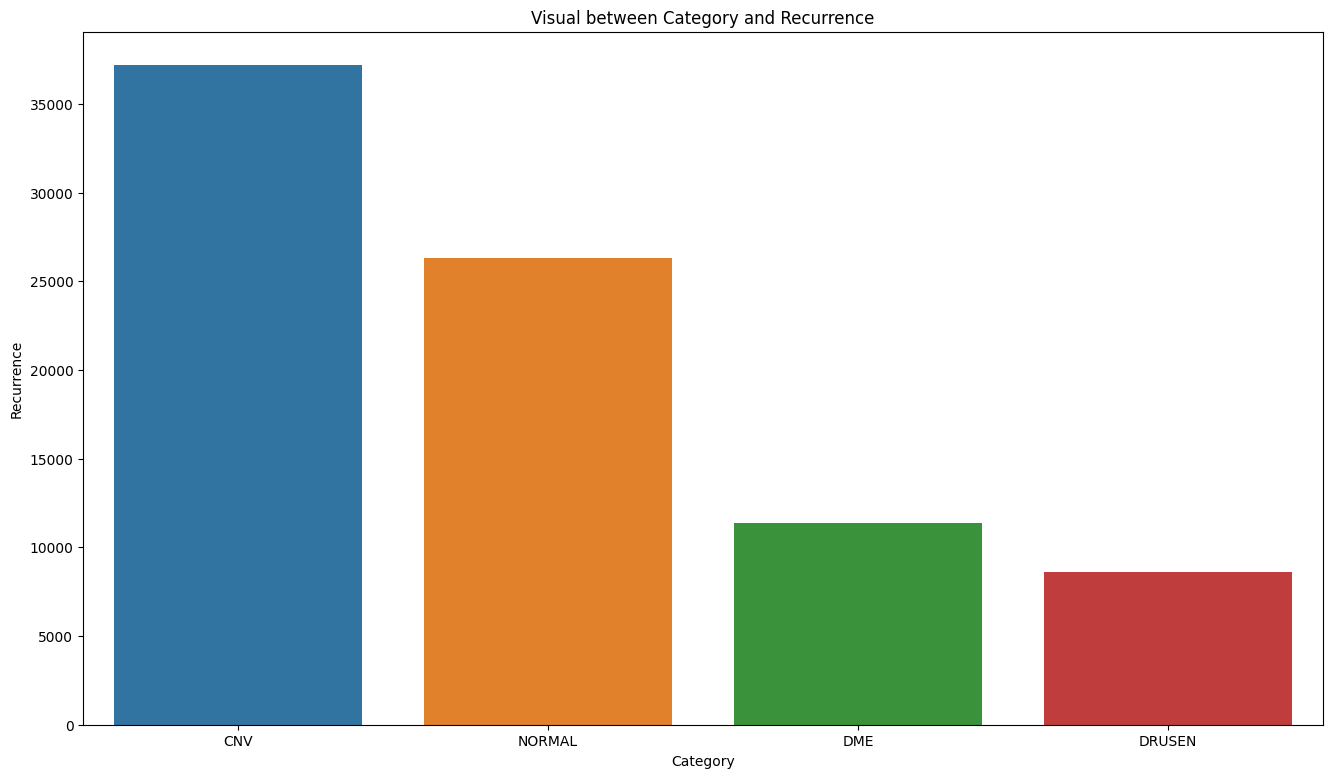

In [ ]:
fig, ax =  plt.subplots(figsize =(16, 9))
ax.set_title('Visual between Category and Recurrence')
plt.xlabel('Category')
plt.ylabel('Recurrence')
dict_type = dict(sorted(dict_type.items(), key=lambda item: item[1],reverse=True))
dict_seaborn ={}
for category , count in dict_type.items():
    dict_seaborn[category] =count
seaborn.barplot(x=list(dict_seaborn.keys()),y=list(dict_seaborn.values()))
plt.show()

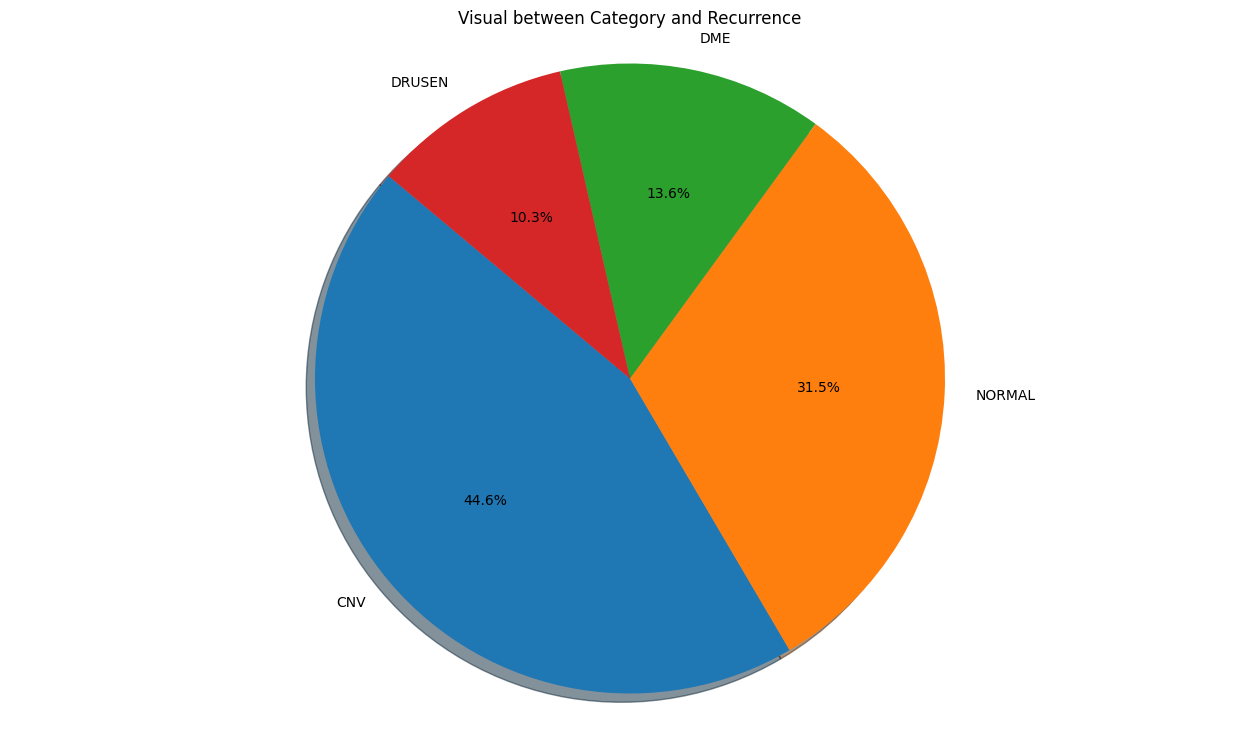

In [ ]:
plt.subplots(figsize =(16, 9))
plt.title('Visual between Category and Recurrence')
labels = dict_seaborn.keys()
sizes = dict_seaborn.values()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.show()

In [ ]:
print("Answer :It becomes clear to us that the category owner of the highest recurrence is "+list(dict_type.keys())[0]+" which amounts to his recurrence {} .".format(list(dict_type.values())[0]))

Answer :It becomes clear to us that the category owner of the highest recurrence is CNV which amounts to his recurrence 37205 .


<a id='pre'></a>
## Preprocessing DataSet

In [ ]:
df_Drusen = df[df['category'] == 'DRUSEN']
df_Cnv = df[df['category'] == 'CNV']
df_Normal = df[df['category'] == 'NORMAL']
df_Dme = df[df['category'] == 'DME']

## We will split each of dataframe to three dataframe ( Train , Validate , Test)
#### Train 80%
#### Valid 20%

### We will split data of Drusen

In [ ]:
# data of Drusen
df_Drusen_old = df_Drusen
validate_df_Drusen = df_Drusen.sample(frac = 0.2)
train_df_Drusen = df_Drusen.drop(validate_df_Drusen.index)
validate_df_Drusen = validate_df_Drusen.reset_index()
train_df_Drusen = train_df_Drusen.reset_index()

In [ ]:
len(df_Drusen_old) , len(train_df_Drusen) , len(validate_df_Drusen)

(8616, 6893, 1723)

### We will split data of Cnv

In [ ]:
# data of Cnv
df_Cnv_old = df_Cnv
validate_df_Cnv = df_Cnv.sample(frac = 0.05)
train_df_Cnv = df_Cnv.drop(validate_df_Cnv.index)
validate_df_Cnv = validate_df_Cnv.reset_index()
train_df_Cnv = train_df_Cnv.reset_index()

test_df_Cnv = train_df_Cnv.sample(frac = 0.7)
train_df_Cnv = train_df_Cnv.drop(test_df_Cnv.index)
test_df_Cnv = test_df_Cnv.reset_index()
train_df_Cnv = train_df_Cnv.reset_index()

In [ ]:
len(df_Cnv_old) , len(train_df_Cnv) , len(validate_df_Cnv) ,len(test_df_Cnv)

(37205, 10603, 1860, 24742)

### We will split data of Normal

In [ ]:
# data of Normal
df_Normal_old = df_Normal
validate_df_Normal= df_Normal.sample(frac = 0.07)
train_df_Normal = df_Normal.drop(validate_df_Normal.index)
validate_df_Normal = validate_df_Normal.reset_index()
train_df_Normal = train_df_Normal.reset_index()

test_df_Normal = train_df_Normal.sample(frac = 0.6)
train_df_Normal = train_df_Normal.drop(test_df_Normal.index)
test_df_Normal = test_df_Normal.reset_index()
train_df_Normal = train_df_Normal.reset_index()

In [ ]:
len(df_Normal_old) , len(train_df_Normal) , len(validate_df_Normal) ,len(test_df_Normal)

(26315, 9789, 1842, 14684)

### We will split data of Dme

In [ ]:
# data of Dme
df_Dme_old = df_Dme
validate_df_Dme = df_Dme.sample(frac = 0.2)
train_df_Dme = df_Dme.drop(validate_df_Dme.index)
validate_df_Dme = validate_df_Dme.reset_index()
train_df_Dme = train_df_Dme.reset_index()

In [ ]:
len(df_Dme_old) , len(train_df_Dme) , len(validate_df_Dme)

(11348, 9078, 2270)

<a id='save'></a>
##  Save DataSet After Preprocessing

In [ ]:
!mkdir TRAIN  TRAIN/DRUSEN TRAIN/CNV TRAIN/NORMAL TRAIN/DME
!mkdir VAL  VAL/DRUSEN VAL/CNV VAL/NORMAL VAL/DME
!mkdir TEST  TEST/DRUSEN TEST/CNV TEST/NORMAL TEST/DME

In [ ]:
IMG_SIZE = (300,300)
def process_save_img(size,full_path_img,name_image,new_folder):
    img = cv2.imread(full_path_img)
    img = cv2.resize(img,dsize=IMG_SIZE,interpolation=cv2.INTER_CUBIC)
    cv2.imwrite(new_folder+'/'+name_image, img)

In [ ]:
#DataSet DME
for filename in tqdm(train_df_Dme['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'TRAIN/DME')
print('finish TRAIN/DME')
for filename in tqdm(validate_df_Dme['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'VAL/DME')
print('finish VAL/DME')

#DataSet NORMAL
for filename in tqdm(train_df_Normal['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'TRAIN/NORMAL')
print('finish TRAIN/NORMAL')
for filename in tqdm(validate_df_Normal['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'VAL/NORMAL')
print('finish VAL/NORMAL')


#DataSet CNV
for filename in tqdm(train_df_Cnv['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'TRAIN/CNV')
print('finish TRAIN/CNV')
for filename in tqdm(validate_df_Cnv['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'VAL/CNV')
print('finish VAL/CNV')


#DataSet DRUSEN
for filename in tqdm(train_df_Drusen['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'TRAIN/DRUSEN')
print('finish TRAIN/DRUSEN')
for filename in tqdm(validate_df_Drusen['filename']):
        name_image = filename.split('/')[-1]
        process_save_img(IMG_SIZE,filename,name_image,'VAL/DRUSEN')
print('finish VAL/DRUSEN')

100%|██████████| 9078/9078 [01:47<00:00, 84.29it/s]


finish TRAIN/DME


100%|██████████| 2270/2270 [00:27<00:00, 83.30it/s]


finish VAL/DME


100%|██████████| 9789/9789 [02:04<00:00, 78.35it/s]


...

finish VAL/CNV


100%|██████████| 6893/6893 [01:30<00:00, 76.00it/s]


finish TRAIN/DRUSEN


100%|██████████| 1723/1723 [00:21<00:00, 79.08it/s]

finish VAL/DRUSEN


In [ ]:
print('Length Of Data { DME } Train : ',len(os.listdir('TRAIN/DME')))
print('Length Of Data { DME } VAL : ',len(os.listdir('VAL/DME')))

print('Length Of Data { NORMAL } Train : ',len(os.listdir('TRAIN/NORMAL')))
print('Length Of Data { NORMAL } VAL : ',len(os.listdir('VAL/NORMAL')))

print('Length Of Data { CNV } Train : ',len(os.listdir('TRAIN/CNV')))
print('Length Of Data { CNV } VAL : ',len(os.listdir('VAL/CNV')))

print('Length Of Data { DRUSEN } Train : ',len(os.listdir('TRAIN/DRUSEN')))
print('Length Of Data { DRUSEN } VAL : ',len(os.listdir('VAL/DRUSEN')))

Length Of Data { DME } Train :  9078
Length Of Data { DME } VAL :  2270
Length Of Data { NORMAL } Train :  9789
Length Of Data { NORMAL } VAL :  1842
Length Of Data { CNV } Train :  10603
Length Of Data { CNV } VAL :  1860
Length Of Data { DRUSEN } Train :  6893
Length Of Data { DRUSEN } VAL :  1723


In [ ]:
train_path = './TRAIN'
test_path = '../input/kermany2018/OCT2017 /test'
valid_path = './VAL'

<a id='cnn'></a>
## CNN Model

<a id='aug'></a>
## Data Augmentation

<a id='apply'></a>
## Apply

In [ ]:
train_gen = ImageDataGenerator(rescale = 1./255,
                                shear_range = 0.2,
                                zoom_range = 0.2,
                                horizontal_flip = True,
                               )

# Create Image Data Generator for Test/Validation Set
test_gen = ImageDataGenerator(rescale = 1./255)




In [ ]:
IMG_SIZE = (224,224)
batch_size = 64

train_generator = ImageDataGenerator(rescale = 1./255,
                                shear_range = 0.2,
                                zoom_range = 0.2,
                                horizontal_flip = True,
                               )

# Create Image Data Generator for Test/Validation Set
test_generator = ImageDataGenerator(rescale = 1./255)

trainRgb = train_generator.flow_from_directory(
      train_path,
      target_size=IMG_SIZE,
      color_mode='rgb',
      class_mode='categorical',
      batch_size=batch_size
      )

testRgb = test_generator.flow_from_directory(
      test_path,
      target_size=IMG_SIZE,
      color_mode='rgb',
      shuffle=False,
      class_mode='categorical',
      batch_size=1
      )

validRgb = test_generator.flow_from_directory(
      valid_path,
      target_size=IMG_SIZE,
      color_mode='rgb',
      class_mode='categorical',
      batch_size=batch_size
      )

Found 36363 images belonging to 4 classes.
Found 968 images belonging to 4 classes.
Found 7695 images belonging to 4 classes.


<a id='demo'></a>
## Demo

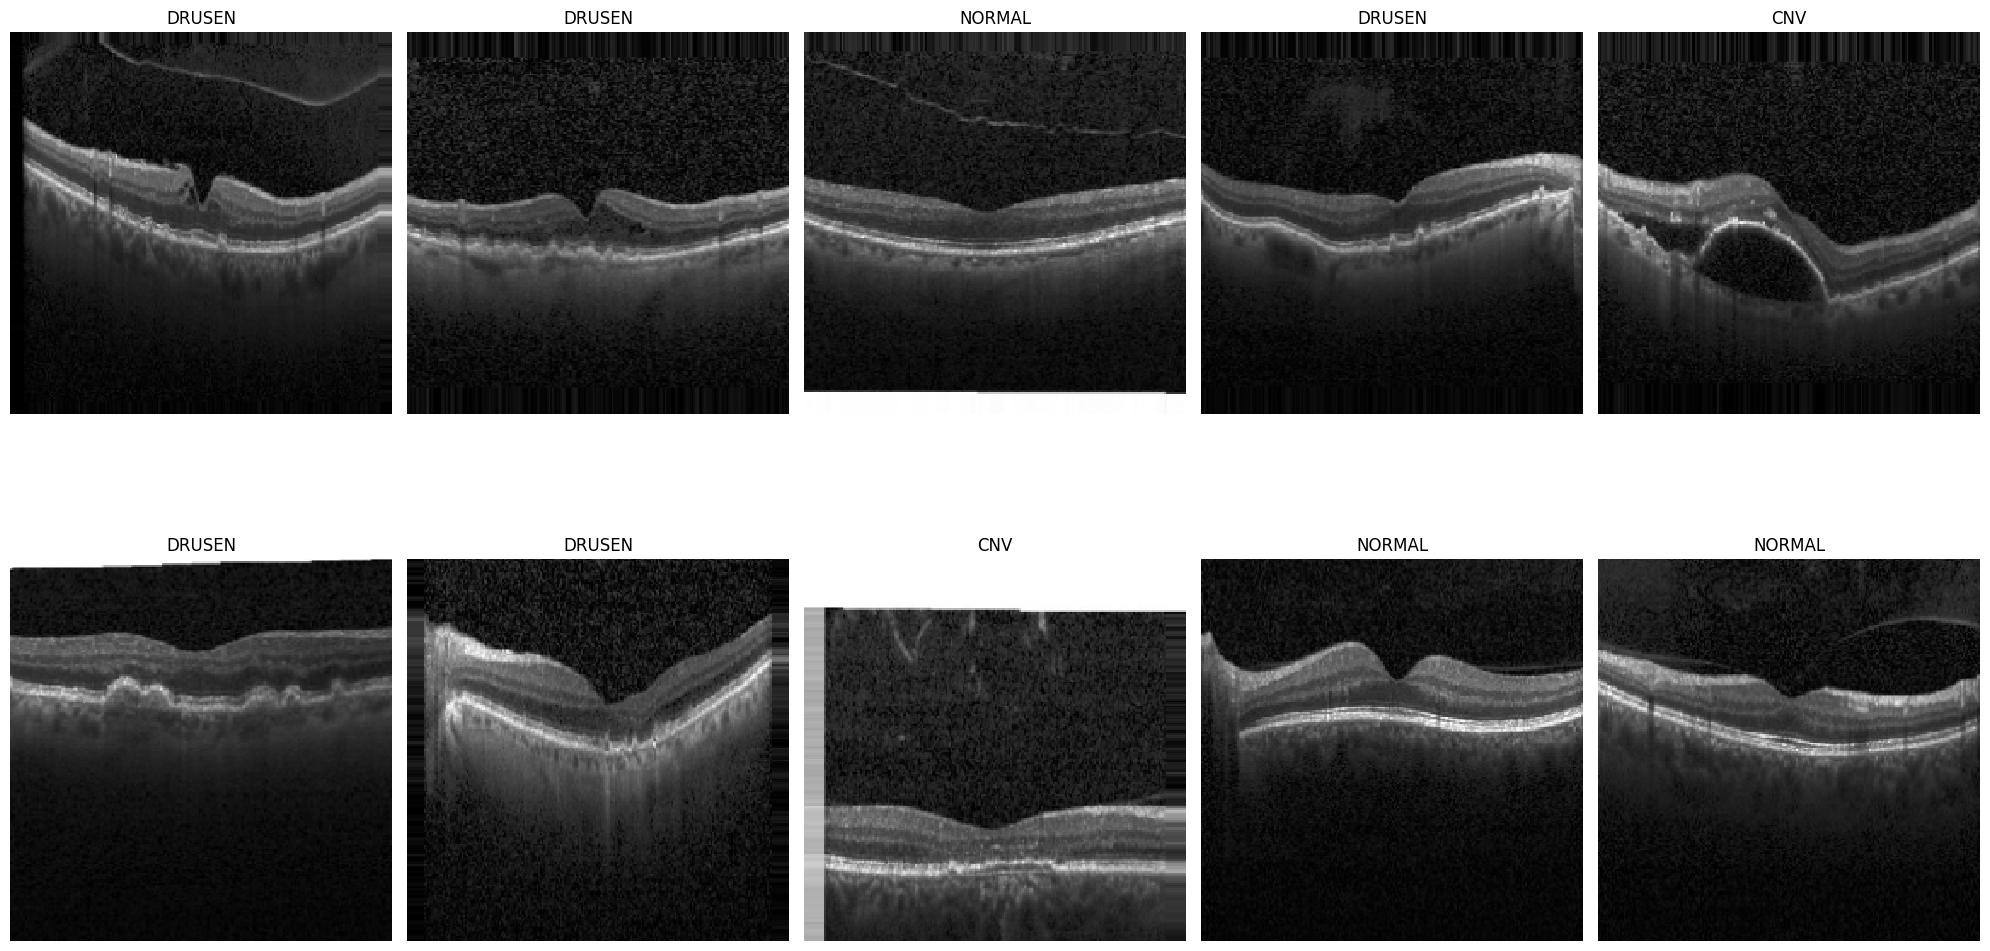

In [ ]:
idx2label_dict = {trainRgb.class_indices[k]: k for k in trainRgb.class_indices}
idx2label_dict
plt.figure(figsize=(20, 12))
for i in range(0, 10):
    plt.subplot(2, 5, i+1)
    for X_batch, Y_batch in trainRgb:
        image = X_batch[0]
        plt.title(idx2label_dict.get(np.argmax(Y_batch[0])))
        plt.axis('off')
        plt.imshow(np.squeeze(image),cmap='gray',interpolation='nearest')
        break
plt.tight_layout()
plt.show()

In [ ]:
early = EarlyStopping(monitor='val_loss', mode='min', patience=4)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)
callbacks_list = [ early, learning_rate_reduction]

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced',classes = np.unique(trainRgb.classes),y = trainRgb.classes)
cw = dict(zip( np.unique(trainRgb.classes), weights))
print(cw)

{0: 0.8573752711496746, 1: 1.0014044943820224, 2: 1.3188379515450457, 3: 0.9286699356420473}


<a id='build'></a>
## Model Building

<a id='scrath'></a>
## Model from Scratch

<a id='scrathf'></a>
## Model from Simple Scratch

In [ ]:
input_shape = (224,224,3)
scratchSimple = Sequential()
scratchSimple.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
scratchSimple.add(MaxPooling2D(pool_size = (2, 2)))
scratchSimple.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
scratchSimple.add(MaxPooling2D(pool_size = (2, 2)))
scratchSimple.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
scratchSimple.add(MaxPooling2D(pool_size = (2, 2)))
scratchSimple.add(Conv2D(64, (3, 3), activation="relu", input_shape=input_shape))
scratchSimple.add(MaxPooling2D(pool_size = (2, 2)))
scratchSimple.add(Conv2D(64, (3, 3), activation="relu", input_shape=input_shape))
scratchSimple.add(MaxPooling2D(pool_size = (2, 2)))
scratchSimple.add(Flatten())
scratchSimple.add(Dense(activation = 'relu', units = 128))
scratchSimple.add(Dense(activation = 'relu', units = 64))
scratchSimple.add(Dense(activation = 'softmax', units = 4))
scratchSimple.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
scratchSimple.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1759513984.784770      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,260 (1.10 MB)

 Trainable params: 288,260 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10

historySimple = scratchSimple.fit(trainRgb,
                            steps_per_epoch=trainRgb.samples//trainRgb.batch_size,
                            validation_data=validRgb,
                            verbose=1,
                            class_weight = cw,
                            validation_steps=validRgb.samples//validRgb.batch_size,
                            epochs=epochs,callbacks=callbacks_list)

test_accu = scratchSimple.evaluate(testRgb)
print('The testing accuracy is :',test_accu[1]*100, '%')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1759513991.819086      89 service.cc:148] XLA service 0x7e0ec02097a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759513991.820087      89 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1759513992.248910      89 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/568 ━━━━━━━━━━━━━━━━━━━━ 1:24:42 9s/step - accuracy: 0.1562 - loss: 1.4226

I0000 00:00:1759513996.828858      89 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


568/568 ━━━━━━━━━━━━━━━━━━━━ 409s 706ms/step - accuracy: 0.5085 - loss: 1.0936 - val_accuracy: 0.7220 - val_loss: 0.7353 - learning_rate: 0.0010
Epoch 2/10
  1/568 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.7031 - loss: 0.7683

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.7031 - loss: 0.7683 - val_accuracy: 0.7397 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 396s 698ms/step - accuracy: 0.7449 - loss: 0.6816 - val_accuracy: 0.7775 - val_loss: 0.5992 - learning_rate: 0.0010
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.8594 - loss: 0.4910 - val_accuracy: 0.7871 - val_loss: 0.5672 - learning_rate: 0.0010
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 396s 697ms/step - accuracy: 0.8022 - loss: 0.5313 - val_accuracy: 0.8546 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 6/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.8281 - loss: 0.4490 - val_accuracy: 0.8543 - val_loss: 0.4029 - learning_rate: 0.0010
Epoch 7/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 396s 697ms/step - accuracy: 0.8523 - loss: 0.4120 - val_accuracy: 0.8763 - val_loss: 0.3410 - learning_rate: 0.0010
Epoch 8/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.9062 - loss: 

In [ ]:
scratchSimple.save('./scratchSimpleP.h5')

<a id='scratchComplex'></a>
## Model from Scrath More Complex

In [ ]:
input_shape = (224,224,3)
scratchComplex = Sequential()
scratchComplex.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(Conv2D(32, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(MaxPooling2D(pool_size = (2, 2)))
scratchComplex.add(BatchNormalization())
scratchComplex.add(Conv2D(64, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(Conv2D(64, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(MaxPooling2D(pool_size = (2, 2)))
scratchComplex.add(BatchNormalization())
scratchComplex.add(Conv2D(64, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(MaxPooling2D(pool_size = (2, 2)))
scratchComplex.add(BatchNormalization())
scratchComplex.add(Dropout(0.10))
scratchComplex.add(Conv2D(128, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(Conv2D(128, (3, 3), activation="relu", input_shape=input_shape))
scratchComplex.add(MaxPooling2D(pool_size = (2, 2)))
scratchComplex.add(BatchNormalization())
scratchComplex.add(Dropout(0.10))
scratchComplex.add(Flatten())
scratchComplex.add(Dense(activation = 'relu', units = 128))
scratchComplex.add(Dense(activation = 'relu', units = 64))
scratchComplex.add(Dense(activation = 'softmax', units = 4))
scratchComplex.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
scratchComplex.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 110, 110, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 53, 53, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 51, 51, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 23, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 21, 21, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,972,132 (7.52 MB)

 Trainable params: 1,971,556 (7.52 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
epochs = 10

historyComplex = scratchComplex.fit(trainRgb,
                            steps_per_epoch=trainRgb.samples//trainRgb.batch_size,
                            validation_data=validRgb,
                            verbose=1,
                            class_weight = cw,
                            validation_steps=validRgb.samples//validRgb.batch_size,
                            epochs=epochs,callbacks=callbacks_list)

test_accu = scratchComplex.evaluate(testRgb)
print('The testing accuracy is :',test_accu[1]*100, '%')

Epoch 1/10


2025-10-03 18:28:19.441696: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[32,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,222,222]{3,2,1,0}, f32[64,32,220,220]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-10-03 18:28:19.652109: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.210531964s
Trying algorithm eng0{} for conv (f32[32,32,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,32,222,222]{3,2,1,0}, f32[64,32,220,220]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","c

568/568 ━━━━━━━━━━━━━━━━━━━━ 431s 726ms/step - accuracy: 0.5565 - loss: 1.1081 - val_accuracy: 0.6783 - val_loss: 0.8513 - learning_rate: 0.0010
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.8906 - loss: 0.3856 - val_accuracy: 0.6557 - val_loss: 0.9276 - learning_rate: 0.0010
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 406s 714ms/step - accuracy: 0.8625 - loss: 0.3933 - val_accuracy: 0.8242 - val_loss: 0.4937 - learning_rate: 0.0010
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.7969 - loss: 0.4761 - val_accuracy: 0.8277 - val_loss: 0.4841 - learning_rate: 0.0010
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 405s 713ms/step - accuracy: 0.8992 - loss: 0.2996 - val_accuracy: 0.8124 - val_loss: 0.5470 - learning_rate: 0.0010
Epoch 6/10
  1/568 ━━━━━━━━━━━━━━━━━━━━ 1:03 112ms/step - accuracy: 0.9688 - loss: 0.1263
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.9688 - loss:

In [ ]:
scratchComplex.save('./scratchComplexP.h5')

 <a id='MobileNet'></a>
## Model MobileNet  

# <a id='trainMobileNet'></a>
## Model MobileNet (  trainable  )    

In [ ]:
input_shape = (224,224,3)
MobileNet= tf.keras.applications.MobileNet(include_top=False,input_shape=input_shape,weights='imagenet')
model_MobileNet = Sequential()
model_MobileNet.add(MobileNet)
model_MobileNet.add(Flatten())
model_MobileNet.add(Dense(512, activation='relu'))
model_MobileNet.add(Dense(4, activation='softmax'))
model_MobileNet.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])
model_MobileNet.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,921,540 (110.33 MB)

 Trainable params: 28,899,652 (110.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
epochs = 10

historyMobileNet = model_MobileNet.fit(trainRgb,
                            steps_per_epoch=trainRgb.samples//trainRgb.batch_size,
                            validation_data=validRgb,
                            verbose=1,
                            class_weight = cw,
                            validation_steps=validRgb.samples//validRgb.batch_size,
                            epochs=epochs,callbacks=callbacks_list)

test_accu = model_MobileNet.evaluate(testRgb)
print('The testing accuracy is :',test_accu[1]*100, '%')

Epoch 1/10


E0000 00:00:1759518264.775260      90 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759518264.978729      90 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


266/568 ━━━━━━━━━━━━━━━━━━━━ 3:26 683ms/step - accuracy: 0.7194 - loss: 1.2183

E0000 00:00:1759518454.968268      90 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1759518455.166853      90 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


568/568 ━━━━━━━━━━━━━━━━━━━━ 446s 731ms/step - accuracy: 0.7847 - loss: 0.8402 - val_accuracy: 0.9066 - val_loss: 0.2660 - learning_rate: 1.0000e-04
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.9375 - loss: 0.1241 - val_accuracy: 0.9100 - val_loss: 0.2608 - learning_rate: 1.0000e-04
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 408s 719ms/step - accuracy: 0.9217 - loss: 0.2292 - val_accuracy: 0.9299 - val_loss: 0.1985 - learning_rate: 1.0000e-04
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.9062 - loss: 0.2304 - val_accuracy: 0.9298 - val_loss: 0.1974 - learning_rate: 1.0000e-04
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 409s 720ms/step - accuracy: 0.9358 - loss: 0.1846 - val_accuracy: 0.9206 - val_loss: 0.2490 - learning_rate: 1.0000e-04
Epoch 6/10
  1/568 ━━━━━━━━━━━━━━━━━━━━ 1:16 134ms/step - accuracy: 0.8594 - loss: 0.4815
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - acc

In [ ]:
model_MobileNet.save('./model_MobileNetP.h5')

 <a id='freezeMobileNet'></a>
## Model MobileNet ( false trainable  )    

In [ ]:
input_shape = (224,224,3)
MobileNet= tf.keras.applications.MobileNet(include_top=False,input_shape=input_shape,weights='imagenet')
for layer in MobileNet.layers:
        layer.trainable=False
model_MobileNetF = Sequential()
model_MobileNetF.add(MobileNet)
model_MobileNetF.add(Flatten())
model_MobileNetF.add(Dense(512, activation='relu'))
model_MobileNetF.add(Dense(4, activation='softmax'))
model_MobileNetF.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])
model_MobileNetF.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,921,540 (110.33 MB)

 Trainable params: 25,692,676 (98.01 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
epochs = 10

historyMobileNetF = model_MobileNetF.fit(trainRgb,
                            steps_per_epoch=trainRgb.samples//trainRgb.batch_size,
                            validation_data=validRgb,
                            verbose=1,
                            class_weight = cw,
                            validation_steps=validRgb.samples//validRgb.batch_size,
                            epochs=epochs,callbacks=callbacks_list)

test_accu = model_MobileNetF.evaluate(testRgb)
print('The testing accuracy is :',test_accu[1]*100, '%')

Epoch 1/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 403s 699ms/step - accuracy: 0.7332 - loss: 1.1908 - val_accuracy: 0.8581 - val_loss: 0.3950 - learning_rate: 1.0000e-04
Epoch 2/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.7656 - loss: 0.6148 - val_accuracy: 0.8566 - val_loss: 0.3911 - learning_rate: 1.0000e-04
Epoch 3/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 396s 697ms/step - accuracy: 0.8631 - loss: 0.3794 - val_accuracy: 0.8646 - val_loss: 0.3750 - learning_rate: 1.0000e-04
Epoch 4/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.8438 - loss: 0.3718 - val_accuracy: 0.8693 - val_loss: 0.3576 - learning_rate: 1.0000e-04
Epoch 5/10
568/568 ━━━━━━━━━━━━━━━━━━━━ 400s 705ms/step - accuracy: 0.8777 - loss: 0.3422 - val_accuracy: 0.8736 - val_loss: 0.3765 - learning_rate: 1.0000e-04
Epoch 6/10
  1/568 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.8594 - loss: 0.4697
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
568/568 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/s

In [ ]:
model_MobileNetF.save('./model_MobileNetFP.h5')

<a id='perf'></a>
## Model Performance

In [ ]:
from keras.models import load_model
model = load_model('/kaggle/working/scratchComplexP.h5')

In [ ]:
idx2label_dict = {testRgb.class_indices[k]: k for k in testRgb.class_indices}
idx2label_dict

{0: 'CNV', 1: 'DME', 2: 'DRUSEN', 3: 'NORMAL'}

968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
confusion matrix :
 [[241   0   1   0]
 [ 14 224   1   3]
 [  1   0 241   0]
 [  0   0   1 241]]
Precision Score :  0.9783057851239669
Recall Score :  0.9783057851239669
classification_report :
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       242
           1       1.00      0.93      0.96       242
           2       0.99      1.00      0.99       242
           3       0.99      1.00      0.99       242

    accuracy                           0.98       968
   macro avg       0.98      0.98      0.98       968
weighted avg       0.98      0.98      0.98       968



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1396: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1396: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


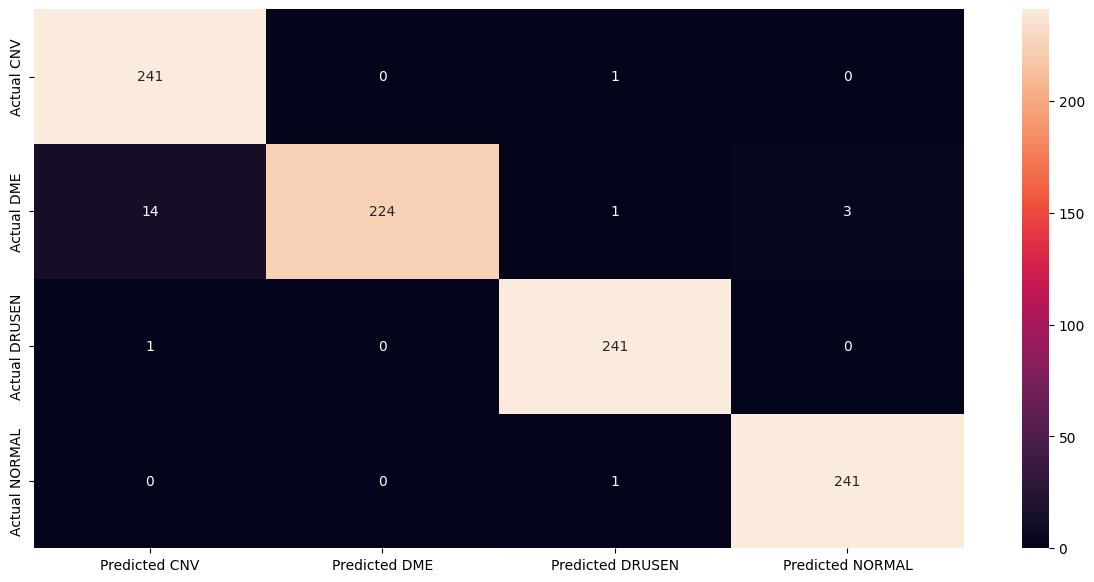

In [ ]:
predict_x=model.predict(testRgb)
y_pred=np.argmax(predict_x,axis=1)
idx2label_dict = {testRgb.class_indices[k]: k for k in testRgb.class_indices}
y_true = testRgb.classes


plt.figure(figsize = (15,7))

cm = pd.DataFrame(data=confusion_matrix(y_true, y_pred, labels=[0, 1,2,3]),

                  index=["Actual " + idx2label_dict[0],
                         "Actual " + idx2label_dict[1],
                         "Actual " + idx2label_dict[2],
                         "Actual " + idx2label_dict[3]],

                  columns=["Predicted "+ idx2label_dict[0],
                           "Predicted "+ idx2label_dict[1],
                           "Predicted "+ idx2label_dict[2],
                           "Predicted "+ idx2label_dict[3]])

seaborn.heatmap(cm,annot=True,fmt="d");

#test_accuracy = model_MobileNet.evaluate(testRgb)
#print('The testing accuracy is :',test_accuracy[1]*100, '%')
print('confusion matrix :\n',confusion_matrix(y_true,y_pred))
print("Precision Score : ",precision_score(y_true, y_pred, pos_label='positive',average='micro'))
print("Recall Score : ",recall_score(y_true, y_pred, pos_label='positive',average='micro'))
print('classification_report :\n',classification_report(y_true,y_pred))

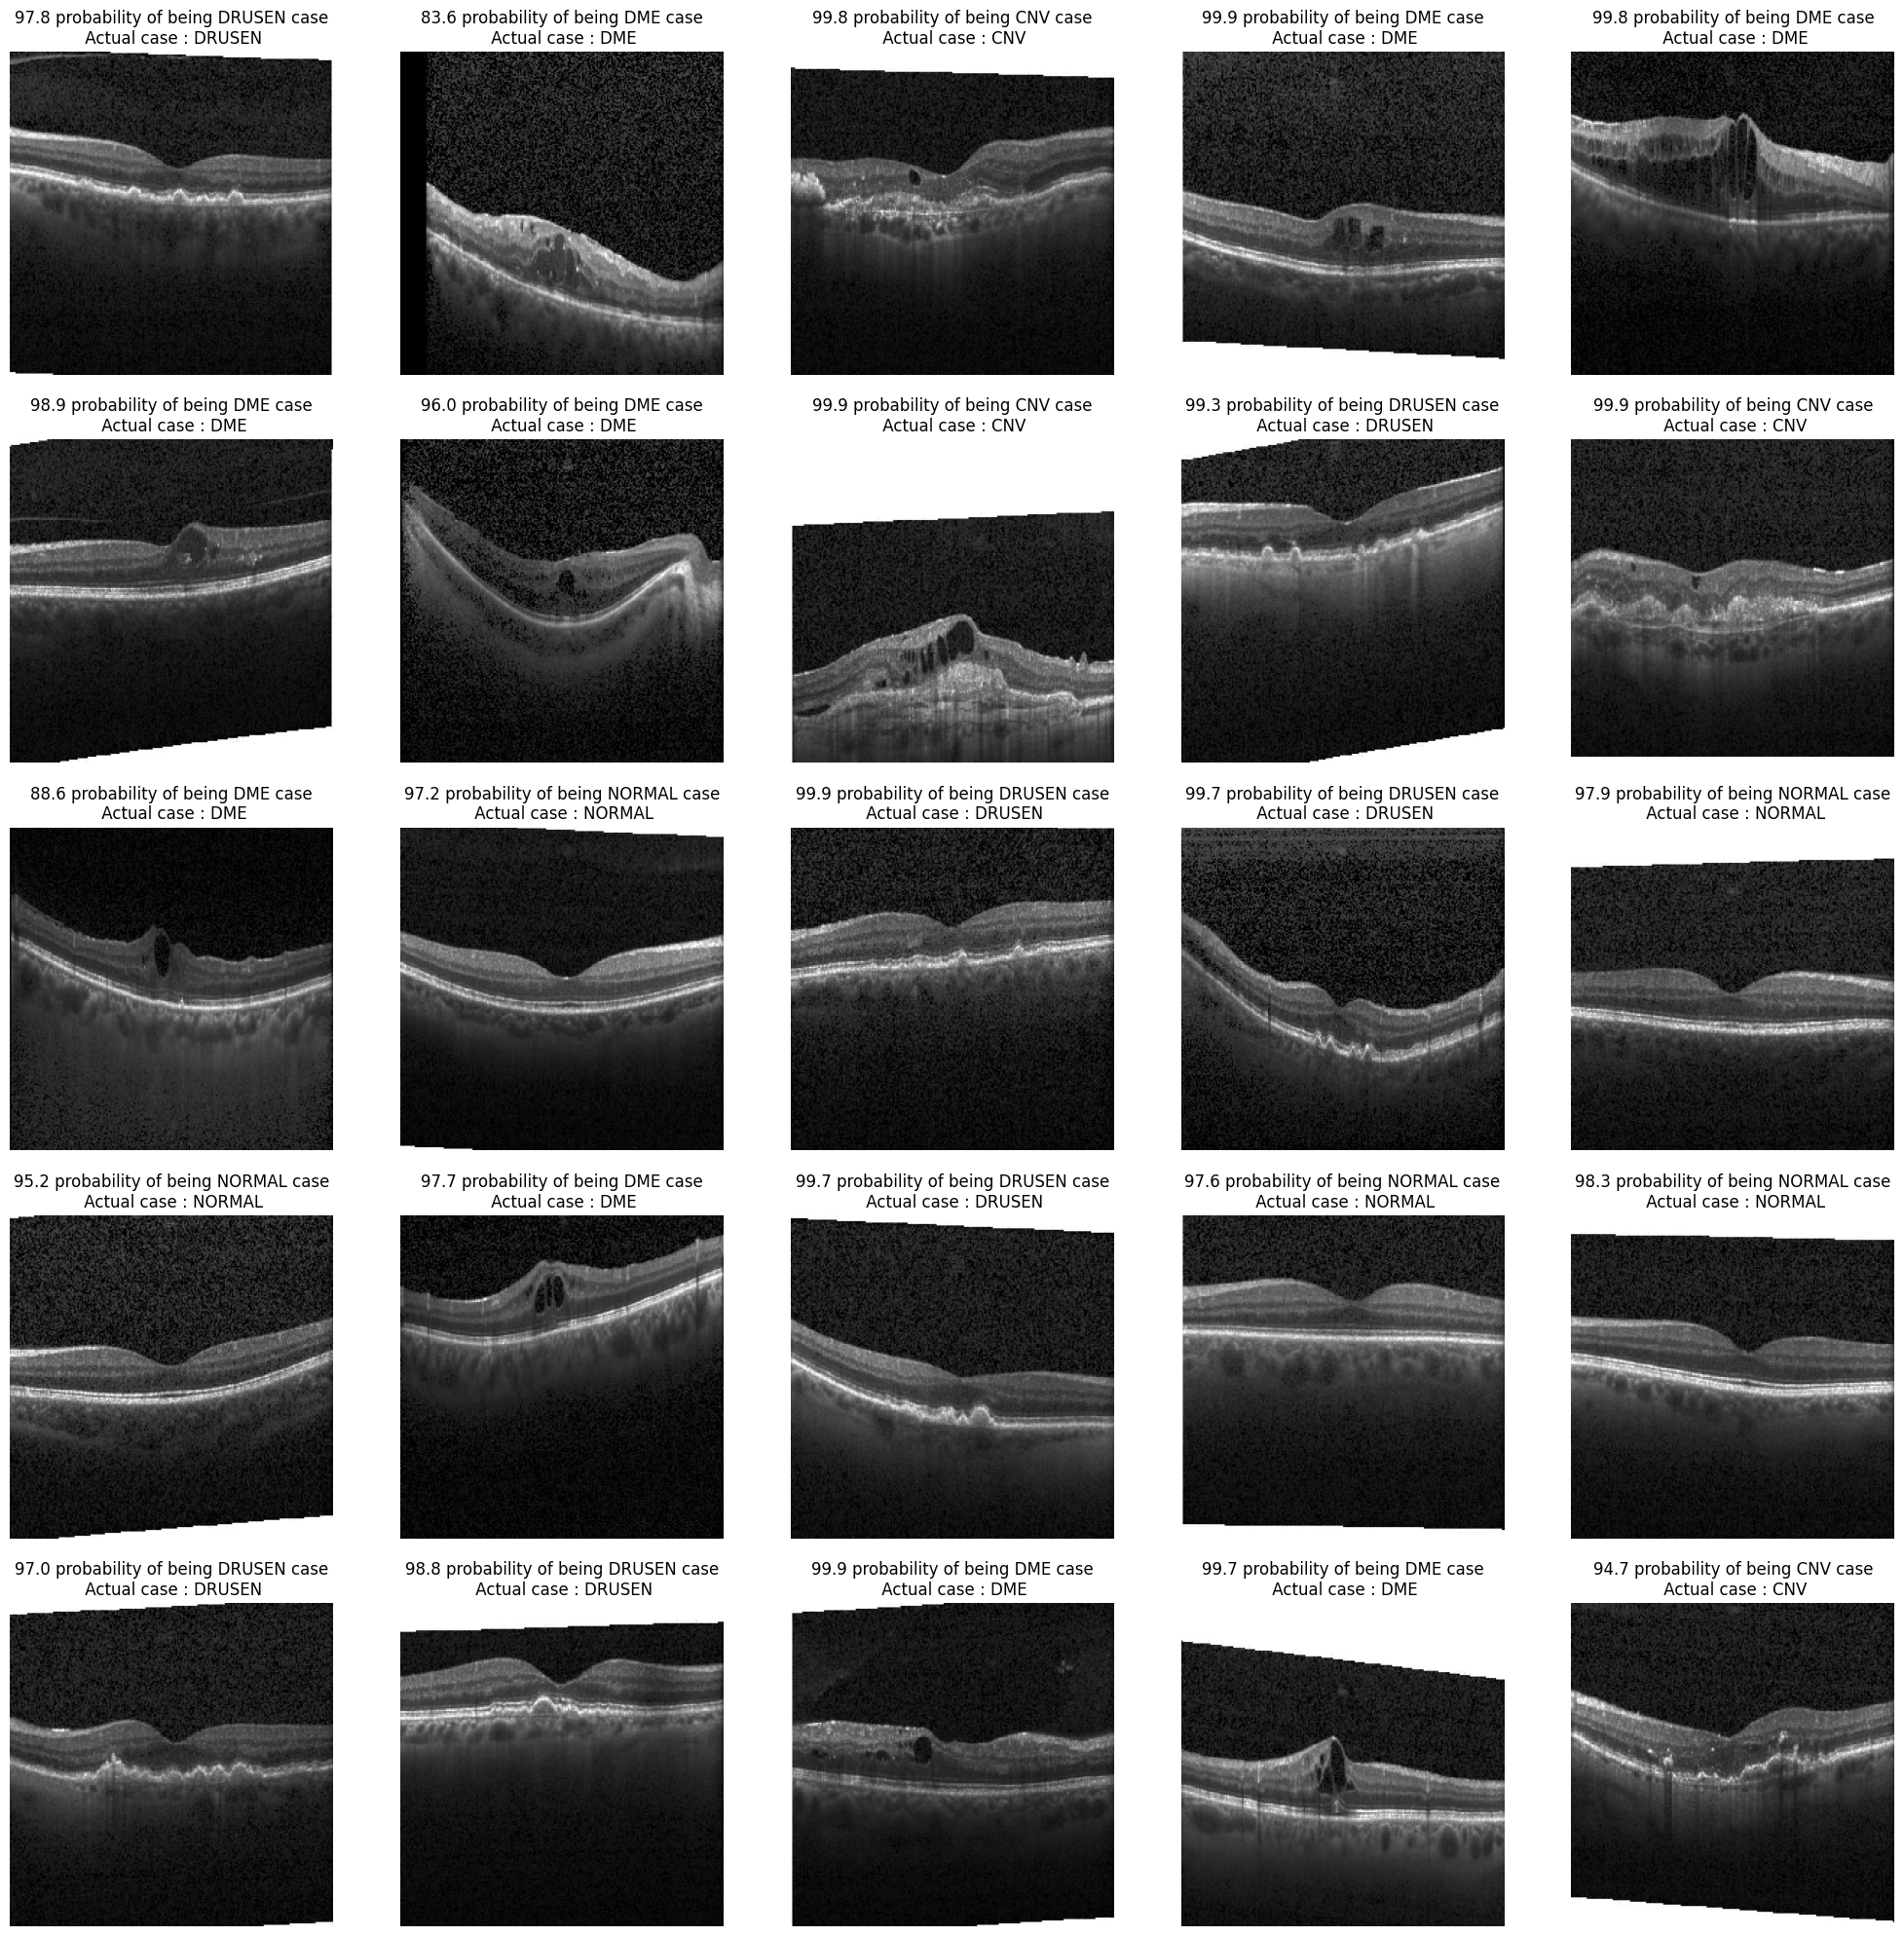

In [ ]:
plt.figure(figsize=(25,25))
randomlist = random.sample(range(0, 968), 25)
index_list = 0
for i in range(0+228, 25+228):
        plt.subplot(5, 5, (i-228)+1)
        #print(predict_x[randomlist[index_list]])
        index = np.argmax(predict_x[randomlist[index_list]],axis=0)
        out = str(predict_x[randomlist[index_list]][index]*100)[:4] + ' probability of being '+idx2label_dict[y_pred[randomlist[index_list]]]+' case'
        #print(y_pred[randomlist[index_list]] ,index , predict_x[randomlist[index_list]][index])
        plt.title(out+"\n Actual case : "+ idx2label_dict.get(y_true[randomlist[index_list]]))
        plt.imshow(np.squeeze(testRgb[randomlist[index_list]][0]))
        plt.axis('off')
        index_list = index_list + 1
plt.show()

# Production
- Lets you upload an image manually.
- Preprocesses it the same way your model expects (resize, normalize, etc.).
- Runs it through your trained model.
- Prints the predicted disease type (class).

In [ ]:
img = cv2.imread('/kaggle/input/kermany2018/OCT2017 /test/CNV/CNV-1016042-1.jpeg')
img = cv2.resize(img,dsize=(224,224),interpolation=cv2.INTER_CUBIC)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
input_arr = tf.keras.preprocessing.image.img_to_array(gray)
input_arr = np.array([input_arr])
input_arr = input_arr.astype('float32') / 255.
predictions = model.predict(input_arr)
print(np.argmax(predictions,axis=1)   ,predictions)
print(np.argmax(predictions,axis=1)   ,predictions[0]*100)
print(np.argmax(predictions,axis=1)   ,predictions[0][1]*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step
[0] [[9.9966145e-01 1.0543173e-04 2.2788918e-04 5.2268474e-06]]
[0] [9.9966141e+01 1.0543173e-02 2.2788918e-02 5.2268471e-04]
[0] 0.01054317326634191


<a id='tensor'></a>
## Convert Model Keras To TensorFlow

In [ ]:
from tensorflow import keras
from tensorflow import lite
converter = lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
open("./complexModel.tflite","wb").write(tflite_model)

Saved artifact at '/tmp/tmpa0xwnw_s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138601914516880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914524944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914525328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914526480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914525136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914526096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914524176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914520144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914520528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138601914527824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386019145276

W0000 00:00:1759522539.485642      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1759522539.485689      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1759522539.503581      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


7895152

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path="./complexModel.tflite")
interpreter.allocate_tensors()

# Print input shape and type
inputs = interpreter.get_input_details()
print('{} input(s):'.format(len(inputs)))
for i in range(0, len(inputs)):
    print('{} {}'.format(inputs[i]['shape'], inputs[i]['dtype']))

# Print output shape and type
outputs = interpreter.get_output_details()
print('\n{} output(s):'.format(len(outputs)))
for i in range(0, len(outputs)):
    print('{} {}'.format(outputs[i]['shape'], outputs[i]['dtype']))

1 input(s):
[  1 224 224   3] <class 'numpy.float32'>

1 output(s):
[1 4] <class 'numpy.float32'>


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
